In [1]:
import comtradeapicall as cd
import pandas as pd
import numpy as np
from comtrade import Comtrade
import requests
import os
from datetime import datetime
import matplotlib.pyplot as plt
from io import BytesIO

In [2]:
url_list= {'Reporter_codes': 'https://comtradeapi.un.org/files/v1/app/reference/Reporters.json', 
           'Partner_codes': 'https://comtradeapi.un.org/files/v1/app/reference/partnerAreas.json'} # https://docs.ropensci.org/comtradr/reference/country_codes.html
# these links go to json files that contain all country codes in UN Comtrade database

codes_dict = {}

try:          #this loop is needed to 2 concise dataframes with country codes
    for name, link in url_list.items():
        data = requests.get(link)
        data.raise_for_status()
        data = data.json()
        
        df = pd.DataFrame(data['results'])
        df.rename(columns = {'text': 'country'}, inplace=True)
        df.set_index('country', inplace=True)
        
        codes_dict[name] = df

except Exception as e:
    print('An error occured, ', e)

In [3]:
def get_code(country: str, df=codes_dict['Partner_codes']) -> int:
    """
    This function returns a code of country you need to proceed with API-call.
    Input: name of country (needs to be the same as in database), output: country's ISO code.
    By default, locates country in Reporter codes. Works only with Partner_codes and Reporter_codes dataframes.
    """
    try:
        return df.loc[country, 'PartnerCode']
    except Exception as e:
        return df.loc[country, 'reporterCode']

def get_country(code: int, df=codes_dict['Partner_codes']) -> str:
    """
    This function returns name of country from ISO code you provide.
    Input: ISO code of country, output: name of country.
    By default, locates country in Partner codes. Works only with Partner_codes and Reporter_codes dataframes.
    """
    dfn = df.reset_index()
    try:
        dfn.set_index('PartnerCode', inplace=True)
    except Exception:
        dfn.set_index('reporterCode', inplace=True)
    return dfn.loc[code, 'country']

In [4]:
nat_gas_codes = ['271111', # Natural gas, liquefied
                 '271121' # Natural gas, gaseous
                 ]
ng_codes_str = ",".join(nat_gas_codes) # api call requires comma-separated string, not list

year_list = list(range(2000, datetime.now().year)) # list of all years from 2000 to now

def month_adder(year: int) -> str:
    """
    This function creates a string of YYYYMM values to call api on every month in this year.
    Input: one year you need to create year+month from.
    Output: string of 12 months of this year.
    """
    year_list = [str(year) + '0' + str(x) if x < 10 else str(year) + str(x) for x in range(1, 13)]
    return ','.join(year_list)


In [5]:
folder_name = 'nat_gas_2000-2025_Trade_data'
os.makedirs(folder_name, exist_ok=True)

In [6]:
# WARNING: TO DOWNLOAD THE DATA YOU NEED ABOUT 60-70 MINUTES!!!

for year in year_list:      
    path = os.path.join(folder_name, str(year))

    if os.path.exists(path):
        print(f'The data for {year} already exists. Proceeding with next year.')
        continue

    print(f'Getting data for {year}')
    try:
        data = cd.getFinalData(subscription_key = 'd4457e079e6240cc8f74def00b4e192f', typeCode='C', 
                           freqCode='M', clCode='HS', period=month_adder(year), reporterCode=None,
                           cmdCode=ng_codes_str, flowCode=None, partnerCode=None, partner2Code=None, 
                           customsCode=None, motCode=None, format_output = 'JSON')
        print(f'Data for {year} is downloaded')
    except Exception as e:
        print(f'An error occured for {year}', e)
    
    data.to_csv(path, index=False)


The data for 2000 already exists. Proceeding with next year.
The data for 2001 already exists. Proceeding with next year.
The data for 2002 already exists. Proceeding with next year.
The data for 2003 already exists. Proceeding with next year.
The data for 2004 already exists. Proceeding with next year.
The data for 2005 already exists. Proceeding with next year.
The data for 2006 already exists. Proceeding with next year.
The data for 2007 already exists. Proceeding with next year.
The data for 2008 already exists. Proceeding with next year.
The data for 2009 already exists. Proceeding with next year.
The data for 2010 already exists. Proceeding with next year.
The data for 2011 already exists. Proceeding with next year.
The data for 2012 already exists. Proceeding with next year.
The data for 2013 already exists. Proceeding with next year.
The data for 2014 already exists. Proceeding with next year.
The data for 2015 already exists. Proceeding with next year.
The data for 2016 alread

In [7]:
df_raw = pd.concat(
    [pd.read_csv(os.path.join(folder_name, str(year))) for year in year_list], ignore_index=True
)
df_raw

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,M,20000101,2000,1,200001,600,NaN,NaN,M,...,26000.0,False,0.0,False,4090.000,2950.000,4090.000,0,False,True
1,C,M,20000101,2000,1,200001,600,NaN,NaN,M,...,26000.0,False,0.0,False,4090.000,2950.000,4090.000,0,False,True
2,C,M,20000101,2000,1,200001,600,NaN,NaN,M,...,26000.0,False,0.0,False,4090.000,2950.000,4090.000,0,True,False
3,C,M,20000101,2000,1,200001,600,NaN,NaN,M,...,26000.0,False,0.0,False,4090.000,2950.000,4090.000,0,False,True
4,C,M,20000101,2000,1,200001,579,NaN,NaN,X,...,32000.0,False,0.0,False,0.000,29235.494,29235.494,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491721,C,M,20241201,2024,12,202412,780,NaN,NaN,M,...,NaN,False,0.0,False,2333.024,NaN,2333.024,0,True,False
491722,C,M,20241201,2024,12,202412,768,NaN,NaN,M,...,2000000.0,False,0.0,False,5980405.036,NaN,5980405.036,0,True,False
491723,C,M,20241201,2024,12,202412,768,NaN,NaN,M,...,2000000.0,False,0.0,False,5980405.036,NaN,5980405.036,0,False,True
491724,C,M,20241201,2024,12,202412,768,NaN,NaN,M,...,2000000.0,False,0.0,False,5980405.036,NaN,5980405.036,0,False,True


In [8]:
df_raw.sample(10).style

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,flowDesc,partnerCode,partnerISO,partnerDesc,partner2Code,partner2ISO,partner2Desc,classificationCode,classificationSearchCode,isOriginalClassification,cmdCode,cmdDesc,aggrLevel,isLeaf,customsCode,customsDesc,mosCode,motCode,motDesc,qtyUnitCode,qtyUnitAbbr,qty,isQtyEstimated,altQtyUnitCode,altQtyUnitAbbr,altQty,isAltQtyEstimated,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
126026,C,M,20131201,2013,12,201312,826,nan,nan,X,nan,372,nan,nan,0,nan,nan,H4,HS,True,271111,nan,nan,nan,C00,nan,0,0,nan,-1,nan,0.000000,False,-1,nan,0.000000,False,297.000000,False,0.000000,False,0.000000,992.307000,992.307000,0,True,False
348320,C,M,20210801,2021,8,202108,428,nan,nan,M,nan,643,nan,nan,643,nan,nan,H5,HS,True,271121,nan,nan,nan,C00,nan,0,0,nan,8,nan,72445300.000000,False,18,nan,3957.000000,False,72445300.000000,False,0.000000,False,46536750.378000,nan,46536750.378000,0,False,True
322139,C,M,20201201,2020,12,202012,404,nan,nan,M,nan,156,nan,nan,0,nan,nan,H5,HS,True,271121,nan,nan,nan,C00,nan,0,2100,nan,8,nan,150.000000,False,8,nan,150.000000,False,150.000000,False,0.000000,False,1127.560000,0.000000,1127.560000,0,True,False
12098,C,M,20030101,2003,1,200301,724,nan,nan,FM,nan,566,nan,nan,0,nan,nan,H2,HS,True,271111,nan,nan,nan,C01,nan,0,0,nan,8,nan,228915000.000000,False,18,nan,12107.800000,False,228915000.000000,False,0.000000,False,41684732.270000,nan,41684732.270000,0,False,True
483402,C,M,20241001,2024,10,202410,703,nan,nan,M,nan,40,nan,nan,40,nan,nan,H6,HS,True,271111,nan,nan,nan,C20,nan,0,0,nan,8,nan,4367590.000000,False,18,nan,56575.000000,False,4367590.000000,False,0.000000,False,2642507.305000,2642507.305000,2642507.305000,0,False,True
122483,C,M,20131001,2013,10,201310,710,nan,nan,DX,nan,426,nan,nan,0,nan,nan,H4,HS,True,271121,nan,nan,nan,C00,nan,0,3200,nan,8,nan,192.000000,False,8,nan,192.000000,False,192.000000,False,0.000000,False,0.000000,2444.693000,2444.693000,0,False,True
30129,C,M,20050801,2005,8,200508,724,nan,nan,M,nan,0,nan,nan,251,nan,nan,H2,HS,True,271111,nan,nan,nan,C20,nan,0,2100,nan,8,nan,79481.900000,False,18,nan,43.000000,False,79481.900000,False,0.000000,False,188402.148000,0.000000,188402.148000,0,False,True
470533,C,M,20240601,2024,6,202406,710,nan,nan,X,nan,426,nan,nan,0,nan,nan,H6,HS,True,271121,nan,nan,nan,C03,nan,0,3200,nan,8,nan,10.900000,False,8,nan,10.900000,False,10.900000,False,0.000000,False,nan,81.230000,81.230000,0,True,False
281583,C,M,20191101,2019,11,201911,780,nan,nan,DX,nan,842,nan,nan,0,nan,nan,H4,HS,True,271111,nan,nan,nan,C00,nan,0,2100,nan,8,nan,76737000.000000,False,12,nan,179972.000000,False,76737000.000000,False,0.000000,False,0.000000,25369358.701000,25369358.701000,0,True,False
247015,C,M,20190101,2019,1,201901,100,nan,nan,XOP,nan,528,nan,nan,0,nan,nan,H5,HS,True,271121,nan,nan,nan,C00,nan,0,0,nan,8,nan,659769.000000,False,18,nan,31.000000,False,659769.000000,False,0.000000,False,0.000000,263852.434000,263852.434000,0,False,True


<Axes: >

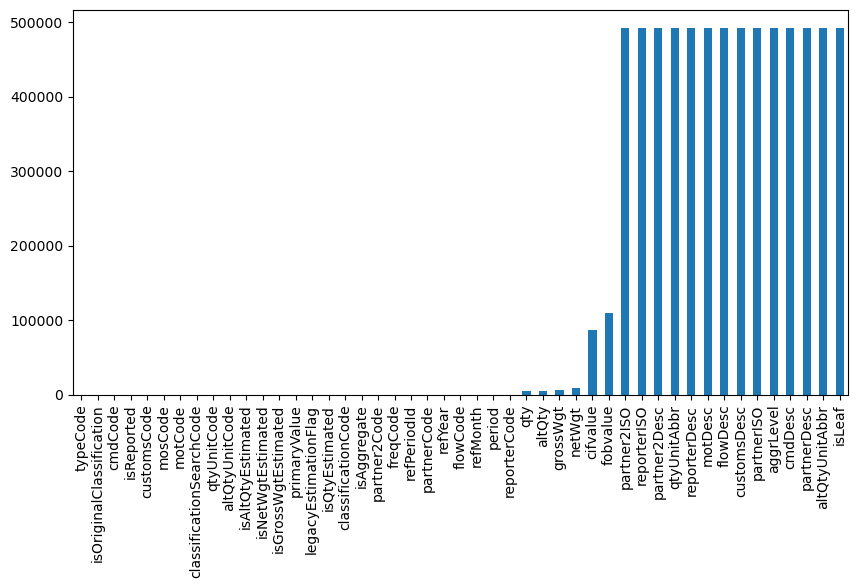

In [9]:
plt.figure(figsize=(10,5))
df_raw.isna().sum().sort_values().plot.bar()

In [10]:
cols_to_keep = ['period', 'refYear', 'refMonth', 'reporterCode', 
                'flowCode', 'partnerCode', 'classificationCode',
                'cmdCode', 'customsCode', 'motCode', 'qtyUnitCode', 'qty', 
                'isQtyEstimated', 'altQtyUnitCode', 'altQty', 'isAltQtyEstimated',
                'netWgt', 'isNetWgtEstimated', 'primaryValue', 'isAggregate']

explanations = {'period': 'YYYYMM of trade', 
                'refYear': 'year of trade', 
                'refMonth': 'month of trade', 
                'reporterCode': 'code of country who reported the trade', 
                'flowCode': 'code of trade flow, usually "M" for "Import" and "X" for "Export" ', 
                'partnerCode': 'code of country who is a counterparty in the trade reported by reporter country ', 
                'classificationCode': 'type of Harmonized System (HS) classification used for this trade. It has changed throughout the years',
                'cmdCode': 'code of commodity traded', 
                'customsCode': 'defines how the goods entered or left the economic territory', 
                'motCode': 'code of transport used to deliver the trade', 
                'qtyUnitCode': 'defines the unit of measurement of commodity traded', 
                'qty': 'quantity of commodity traded measured in a way specified in qtyUnitCode', 
                'isQtyEstimated': 'Is quantity Estimated - boolean', 
                'altQtyUnitCode': 'alternative unit of measurement of commodity traded', 
                'altQty': 'quantity of commodity traded measured in altQtyUnitCode units', 
                'isAltQtyEstimated': 'Is alternative quantity Estimated - boolean',
                'netWgt': 'net weight of commodity traded in kilograms', 
                'isNetWgtEstimated': 'Is quantity Estimated - boolean', 
                'primaryValue': 'value of trade in dollars',
                'isAggregate': 'is value aggregated - True or False'}


In [11]:
df = df_raw[cols_to_keep].copy()
df

,period,refYear,refMonth,reporterCode,flowCode,partnerCode,classificationCode,cmdCode,customsCode,motCode,qtyUnitCode,qty,isQtyEstimated,altQtyUnitCode,altQty,isAltQtyEstimated,netWgt,isNetWgtEstimated,primaryValue,isAggregate
0,200001,2000,1,600,M,0,H1,271111,C00,0,8,26000.0,False,8,26000.0,False,26000.0,False,4090.000,True
1,200001,2000,1,600,M,0,H1,271111,C00,0,8,26000.0,False,8,26000.0,False,26000.0,False,4090.000,True
2,200001,2000,1,600,M,76,H1,271111,C00,0,8,26000.0,False,8,26000.0,False,26000.0,False,4090.000,False
3,200001,2000,1,600,M,76,H1,271111,C00,0,8,26000.0,False,8,26000.0,False,26000.0,False,4090.000,True
4,200001,2000,1,579,X,0,H1,271111,C00,0,8,32000.0,False,8,32000.0,False,32000.0,False,29235.494,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491721,202412,2024,12,780,M,842,H4,271121,C00,1000,-1,0.0,False,12,3.0,False,NaN,False,2333.024,False
491722,202412,2024,12,768,M,566,H5,271111,C01,0,8,2000000.0,False,8,2000000.0,False,2000000.0,False,5980405.036,False
491723,202412,2024,12,768,M,0,H5,271111,C00,0,8,2000000.0,False,8,2000000.0,False,2000000.0,False,5980405.036,True
491724,202412,2024,12,768,M,0,H5,271111,C01,0,8,2000000.0,False,8,2000000.0,False,2000000.0,False,5980405.036,True


In [12]:
response = requests.get('https://comtradeapi.un.org/files/v1/app/wiki/ComtradePlus_DataItems.xlsx')
response.raise_for_status()
if response.status_code == 200:
    excel_codes = pd.ExcelFile(BytesIO(response.content))
print(excel_codes.sheet_names)       

#It is difficult to make everything nicer here (e.g by function) so I needed to create manually these dfs for further comfortable usage
# This dataframes are needed to convert codes in some columns to human-readable words.

flow_codes = pd.read_excel(excel_codes, sheet_name='REF FLOWS')
flow_codes.set_index('flwCode', inplace=True)

mot_codes = pd.read_excel(excel_codes, sheet_name = 'REF MOT')
mot_codes.set_index('motCode', inplace=True)

qty_codes = pd.read_excel(excel_codes, sheet_name = 'REF QTY')
qty_codes.set_index('qtyCode', inplace=True)

customs_codes = pd.read_excel(excel_codes, sheet_name = 'REF CUSTOMS')
customs_codes.set_index('cstCode', inplace=True)

country_codes = pd.read_excel(excel_codes, sheet_name = 'REF COUNTRIES')
country_codes.set_index('geoAreaCode', inplace=True)

['COMTRADE+ COMPLETE', 'REF COUNTRIES', 'REF MOT', 'REF QTY', 'REF CUSTOMS', 'REF FLOWS', 'REF  MOS']


In [13]:
qty_codes

,qtyAbbr,qtyDescription
qtyCode,,
-1,NaN,Not available or not specified or no quantity.
2,m²,Area in square meters
3,1000 kWh,Electrical energy in thousands of kilowatt-hours
4,m,Length in meters
5,u,Number of items
6,2u,Number of pairs
7,l,Volume in liters
8,kg,Weight in kilograms
9,1000u,Thousand of items


In [14]:
df['reporter'] = df.reporterCode.apply(lambda x: country_codes.loc[x]) # adding name of reporters
df['partner'] = df.partnerCode.apply(lambda x: country_codes.loc[x]) # adding name of partners

df['flow'] = df.flowCode.apply(lambda x: "Import" if "M" in x else "Export" if "X" in x else "None") # adding category of flow: Import/Export
df['flow_detail'] = df.flowCode.apply(lambda x: flow_codes.loc[x, 'flwDescription']) # adding detailed type of flow (Re-import etc.)

df['transport'] = df.motCode.apply(lambda x: mot_codes.loc[x]) # adding name of category of transport

df['quantity'] = df.qtyUnitCode.apply(lambda x: qty_codes.loc[x, 'qtyAbbr']) # adding unit symbols of quantities (kg - kilograms, m^3. -cubic meters, NaN - unspecified )
df['alt_quantity'] = df.altQtyUnitCode.apply(lambda x: qty_codes.loc[x, 'qtyDescription']) # here I added description indtead of unit symbols because units are very different and not understandable
df['customs'] = df.customsCode.apply(lambda x: customs_codes.loc[x]) #adding names of custom procedures

In [15]:
df['period'] = pd.to_datetime(df['period'].astype(str), format = '%Y%m') # now we have it in date format to easily work with time series

In [16]:
df.sample(7).style

,period,refYear,refMonth,reporterCode,flowCode,partnerCode,classificationCode,cmdCode,customsCode,motCode,qtyUnitCode,qty,isQtyEstimated,altQtyUnitCode,altQty,isAltQtyEstimated,netWgt,isNetWgtEstimated,primaryValue,isAggregate,reporter,partner,flow,flow_detail,transport,quantity,alt_quantity,customs
382914,2022-06-01 00:00:00,2022,6,76,M,0,H6,271121,C00,0,-1,0.000000,False,8,341777201.000000,False,0.000000,False,115441178.000000,True,Brazil,World,Import,Import,Total Modes of Transport,nan,Weight in kilograms,TOTAL CPC
270949,2019-08-01 00:00:00,2019,8,724,DX,705,H5,271111,C20,0,8,1527.000000,False,18,0.080000,False,1527.000000,False,7203.755000,True,Spain,Slovenia,Export,Domestic Export,Total Modes of Transport,kg,Terajoule (gross calorific value),CPC N.E.S.
412599,2023-02-01 00:00:00,2023,2,710,DX,748,H6,271111,C03,3200,8,256630.275000,True,-1,0.000000,False,256630.275000,True,178540.684000,False,South Africa,Eswatini,Export,Domestic Export,Road,kg,Not available or not specified or no quantity.,Outright exportation
226095,2018-05-01 00:00:00,2018,5,710,X,748,H5,271111,C03,0,8,65355.600000,False,8,65355.600000,False,65355.600000,False,68691.979000,True,South Africa,Eswatini,Export,Export,Total Modes of Transport,kg,Weight in kilograms,Outright exportation
33645,2006-01-01 00:00:00,2006,1,724,FM,842,H2,271111,C01,2100,8,45386200.000000,False,18,2500.090000,False,45386200.000000,False,13966986.489000,True,Spain,United States of America,Import,Foreign Import,Sea,kg,Terajoule (gross calorific value),Clearance for home use
334974,2021-04-01 00:00:00,2021,4,233,M,0,H5,271121,C00,0,8,31718172.000000,False,18,1622.382000,False,31718172.000000,False,9855202.690000,True,Estonia,World,Import,Import,Total Modes of Transport,kg,Terajoule (gross calorific value),TOTAL CPC
413410,2023-02-01 00:00:00,2023,2,724,M,0,H6,271111,C00,9100,8,183655500.000000,False,18,9465.167000,False,183655500.000000,False,124877289.996000,True,Spain,World,Import,Import,Pipelines and cables,kg,Terajoule (gross calorific value),TOTAL CPC
